# South African Job Market Intelligence & ML

## Project Overview

This project analyzes current South African job-market listings
to identify employment trends, in-demand skills, technologies,
and characteristics associated with different technology roles.

The project will ultimately develop a machine-learning model
capable of classifying technology job postings based on their
descriptions and extracted features.

### Objectives

1. Explore the South African technology job market.
2. Identify in-demand technical skills.
3. Analyze job requirements, locations, experience and salaries.
4. Apply NLP techniques to job descriptions.
5. Train and compare machine-learning classification models.
6. Evaluate the final model using appropriate metrics.
7. Develop an interactive interface for predictions.



In [89]:
# ============================================================
# South African Job Market Intelligence & ML
# Notebook: 01 - Data Acquisition
# ============================================================

import sys
import platform

print(f"Python version: {sys.version}")
print(f"Platform: {platform.platform()}")

Python version: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


In [90]:
# Core data science libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

# Reproducibility
RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Project Configuration

We define project-wide settings here so that important
parameters are easy to find and modify.

In [91]:
# Project configuration

PROJECT_NAME = "South African Job Market Intelligence & ML"

# Reproducibility
RANDOM_STATE = 42

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print(f"Project: {PROJECT_NAME}")
print(f"Random state: {RANDOM_STATE}")

Project: South African Job Market Intelligence & ML
Random state: 42


## 2. Data Source Investigation

### Primary source
JVR Jobs — South African Job Market Intelligence

The source provides current vacancy listings and market-level
aggregations. We will inspect the available data before designing
our machine-learning pipeline.

### Key considerations

- The data represents vacancy listings, not confirmed hires.
- A listing may represent more than one position.
- Imported listings may originate from external job sources.
- We will document the collection date and source.
- We will assess duplicates and missing values before modelling.

In [92]:
# Data source configuration

DATA_SOURCE = "JVR Jobs"
SOURCE_URL = "https://jvrjobs.co.za/job-market-insights/"

print(f"Data source: {DATA_SOURCE}")
print(f"Source URL: {SOURCE_URL}")

Data source: JVR Jobs
Source URL: https://jvrjobs.co.za/job-market-insights/


## Data Connection Test

Before attempting to collect data, we test whether the public
job-feed page can be accessed programmatically.

In [93]:
# Data acquisition and parsing
import requests
from bs4 import BeautifulSoup

# Utilities
import time
import re
from datetime import datetime

print("Acquisition libraries loaded successfully.")

Acquisition libraries loaded successfully.


In [94]:
# Test connection to the job-feed source

url = "https://jvrjobs.co.za/job-feed/"

try:
    response = requests.get(
        url,
        timeout=15,
        headers={
            "User-Agent": "Mozilla/5.0"
        }
    )

    print("Connection successful!")
    print("Status code:", response.status_code)
    print("Content type:", response.headers.get("content-type"))
    print("Response size:", len(response.text))

except requests.exceptions.Timeout:
    print("Connection timed out.")
    print("The website did not respond within the time limit.")

except requests.exceptions.RequestException as e:
    print("Connection failed.")
    print(f"Error: {e}")

Connection timed out.
The website did not respond within the time limit.


## 4. Data Acquisition

### Data source

Job Opportunities API — public job listings.

We will initially retrieve a sample of South African job
postings and evaluate the available fields before building
the full data pipeline.

### Initial objectives

1. Retrieve South African job listings.
2. Inspect the available fields.
3. Examine the quality and completeness of the data.
4. Identify fields suitable for exploratory analysis.
5. Determine whether the descriptions are suitable for NLP.

In [95]:
# Job Opportunities API
API_URL = "https://api.jobopportunitiesapi.org/public/jobs"

params = {
    "country": "ZA",
    "limit": 10
}

try:
    response = requests.get(
        API_URL,
        params=params,
        timeout=30
    )

    response.raise_for_status()

    jobs_response = response.json()

    print("Connection successful!")
    print("Status code:", response.status_code)
    print("Number of records:", len(jobs_response.get("data", [])))

except requests.exceptions.RequestException as e:
    print(f"Request failed: {e}")

Connection successful!
Status code: 200
Number of records: 10


In [96]:
# Inspect the structure of the API response

jobs = jobs_response.get("data", [])

if jobs:
    print("First job record:")
    print(jobs[0])
else:
    print("No job records returned.")

First job record:
{'id': 'fe77d48b-6aeb-4a58-a2f2-d6f602cd4de9', 'slug': 'distribution-manager-fe77d48b', 'title': 'Distribution Manager', 'company': 'Standard Bank Group', 'company_slug': 'standard-bank-group', 'company_logo': 'https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/standard-bank.png', 'category': 'Logistics & Transport', 'category_confidence': 0.95, 'country': 'ZA', 'location': 'Boland West Coast, Western Cape, South Africa', 'remote': 'on_site', 'remote_inferred': False, 'seniority': 'Manager', 'posted_at': '2026-09-26T14:06:18Z', 'first_seen_at': '2026-09-26T15:21:44Z', 'last_verified_at': '2026-09-26T16:12:05Z', 'status': 'live', 'closed_at': None, 'closed_reason': None, 'apply_url': 'https://jobs.smartrecruiters.com/StandardBankGroup/9a5f97aa-943f-43b8-bd4f-620e0fc89c7c', 'source': 'smartrecruiters', 'source_type': 'ats', 'provider_type': 'employer_ats', 'has_description': False, 'description_length': 0, 'field_sources': {'remote': 'publish

## 5. Initial Data Inspection

Before cleaning or modelling the data, we inspect the structure
of the returned job records.

We want to understand:

- Available fields
- Data types
- Number of records
- Missing values
- Whether job descriptions are available
- Whether enough information exists for machine learning

In [97]:
# Convert the API response into a DataFrame

jobs_df = pd.DataFrame(jobs)

print(f"Rows: {jobs_df.shape[0]}")
print(f"Columns: {jobs_df.shape[1]}")

print("\nColumns:")
for column in jobs_df.columns:
    print(f" - {column}")

Rows: 10
Columns: 30

Columns:
 - id
 - slug
 - title
 - company
 - company_slug
 - company_logo
 - category
 - category_confidence
 - country
 - location
 - remote
 - remote_inferred
 - seniority
 - posted_at
 - first_seen_at
 - last_verified_at
 - status
 - closed_at
 - closed_reason
 - apply_url
 - source
 - source_type
 - provider_type
 - has_description
 - description_length
 - field_sources
 - city
 - employment_type
 - expires_at
 - source_requisition_id


In [98]:
# Inspect the DataFrame structure

jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     10 non-null     object 
 1   slug                   10 non-null     object 
 2   title                  10 non-null     object 
 3   company                10 non-null     object 
 4   company_slug           10 non-null     object 
 5   company_logo           10 non-null     object 
 6   category               6 non-null      object 
 7   category_confidence    6 non-null      float64
 8   country                10 non-null     object 
 9   location               10 non-null     object 
 10  remote                 10 non-null     object 
 11  remote_inferred        10 non-null     bool   
 12  seniority              6 non-null      object 
 13  posted_at              10 non-null     object 
 14  first_seen_at          10 non-null     object 
 15  last_veri

In [99]:
# Display the first 5 records

display(jobs_df.head())

,id,slug,title,company,company_slug,company_logo,category,category_confidence,country,location,remote,remote_inferred,seniority,posted_at,first_seen_at,last_verified_at,status,closed_at,closed_reason,apply_url,source,source_type,provider_type,has_description,description_length,field_sources,city,employment_type,expires_at,source_requisition_id
0,fe77d48b-6aeb-4a58-a2f2-d6f602cd4de9,distribution-manager-fe77d48b,Distribution Manager,Standard Bank Group,standard-bank-group,https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/standard-bank.png,Logistics & Transport,0.95,ZA,"Boland West Coast, Western Cape, South Africa",on_site,False,Manager,2026-09-26T14:06:18Z,2026-09-26T15:21:44Z,2026-09-26T16:12:05Z,live,None,None,https://jobs.smartrecruiters.com/StandardBankGroup/9a5f97aa-943f-43b8-bd4f-620e0fc89c7c,smartrecruiters,ats,employer_ats,False,0,"{'remote': 'published', 'employment_type': 'absent', 'category': 'inferred', 'seniority': 'inferred', 'salary': 'absent', 'salary_max': 'absent', ...",NaN,NaN,NaN,NaN
1,d4ede08a-0578-4d73-99e3-bdd626f0dd95,private-banking-relationship-manager-d4ede08a,Private Banking Relationship Manager,Standard Bank Group,standard-bank-group,https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/standard-bank.png,Finance,0.95,ZA,"Cape Town, WC, South Africa",on_site,False,Manager,2026-09-26T13:26:00Z,2026-09-26T15:21:44Z,2026-09-26T15:53:51Z,live,None,None,https://jobs.smartrecruiters.com/StandardBankGroup/7df6ddd2-9aa5-4a92-9351-6854a667ffc3,smartrecruiters,ats,employer_ats,False,0,"{'remote': 'published', 'employment_type': 'absent', 'category': 'inferred', 'seniority': 'inferred', 'salary': 'absent', 'salary_max': 'absent', ...",Cape Town,NaN,NaN,NaN
2,eb61c560-04e8-4dfd-a03a-648ac603d879,universal-banker-eb61c560,Universal Banker,Standard Bank Group,standard-bank-group,https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/standard-bank.png,NaN,NaN,ZA,"Cape Town, Western Cape, South Africa",on_site,False,Entry,2026-09-26T13:20:32Z,2026-09-26T15:21:44Z,2026-09-26T16:02:30Z,live,None,None,https://jobs.smartrecruiters.com/StandardBankGroup/842c648d-0e97-4894-b940-41af2bb66829,smartrecruiters,ats,employer_ats,False,0,"{'remote': 'published', 'employment_type': 'absent', 'category': 'absent', 'seniority': 'inferred', 'salary': 'absent', 'salary_max': 'absent', 's...",Cape Town,NaN,NaN,NaN
3,f05a3a36-950a-4e2f-95c3-879493a21aca,product-manager-deployment-strategist-f05a3a36,Product Manager (Deployment Strategist),pwc,pwc,https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/pwc.png,Product,0.80,ZA,Johannesburg,on_site,True,Manager,2026-09-25T19:09:50Z,2026-09-25T19:16:54Z,2026-09-26T16:04:20Z,live,None,None,https://pwc.wd3.myworkdayjobs.com/global_experienced_careers/job/Johannesburg/Product-Manager--Deployment-Strategist-_763930WD,workday,ats,employer_ats,True,6526,"{'remote': 'inferred', 'employment_type': 'absent', 'category': 'inferred', 'seniority': 'inferred', 'salary': 'absent', 'salary_max': 'absent', '...",Johannesburg,NaN,NaN,NaN
4,e647b3d6-abb8-403c-9d23-f44102906b84,procurement-managed-services-graduate-interns-2027-e647b3d6,Procurement Managed Services Graduate Interns 2027,pwc,pwc,https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/pwc.png,Procurement,0.80,ZA,Johannesburg,on_site,True,Entry,2026-09-25T19:09:50Z,2026-09-25T19:16:54Z,2026-09-25T19:50:19Z,live,None,None,https://pwc.wd3.myworkdayjobs.com/global_experienced_careers/job/Johannesburg/Procurement-Managed-Services-Graduate-Interns-2027_763087WD,workday,ats,employer_ats,True,7227,"{'remote': 'inferred', 'employment_type': 'absent', 'category': 'inferred', 'seniority': 'inferred', 'salary': 'absent', 'salary_max': 'absent', '...",Johannesburg,NaN,NaN,NaN


## 6. Job Description Investigation

The initial jobs endpoint provides metadata about each vacancy.

Before building an NLP model, we need to determine whether the
full job description can be retrieved for individual listings.

The `has_description` field indicates whether a description exists,
while `description_length` provides an indication of the amount
of available text.

In [100]:
# Check description availability

description_summary = jobs_df[
    ["id", "title", "has_description", "description_length"]
].copy()

display(description_summary)

,id,title,has_description,description_length
0,fe77d48b-6aeb-4a58-a2f2-d6f602cd4de9,Distribution Manager,False,0
1,d4ede08a-0578-4d73-99e3-bdd626f0dd95,Private Banking Relationship Manager,False,0
2,eb61c560-04e8-4dfd-a03a-648ac603d879,Universal Banker,False,0
3,f05a3a36-950a-4e2f-95c3-879493a21aca,Product Manager (Deployment Strategist),True,6526
4,e647b3d6-abb8-403c-9d23-f44102906b84,Procurement Managed Services Graduate Interns 2027,True,7227
5,80b064dd-f11c-4ce1-aa2d-bd91675ffe2e,Procurement Managed Services Graduate Interns 2027,True,7458
6,07f739ae-de78-42c4-88f3-d3b2b83c3fd5,Full Stack Software Engineer,True,8003
7,3d14edb6-e3ed-436e-978f-c5da6595f0ac,Executive: Sales and Commercialisation,False,0
8,067de2f8-e397-40ec-8e83-5c1d68185b89,Senior Multimedia Designer - Motion Graphics Artist,False,0
9,33d139f0-1601-4233-bb06-fd3c45273a7a,SCC Technical Coordinator,True,5449


In [101]:
# Summarize description availability

print("Jobs with descriptions:")
print(jobs_df["has_description"].value_counts())

print("\nDescription length statistics:")
print(jobs_df["description_length"].describe())

Jobs with descriptions:
has_description
False    5
True     5
Name: count, dtype: int64

Description length statistics:
count      10.000000
mean     3466.300000
std      3712.250322
min         0.000000
25%         0.000000
50%      2724.500000
75%      7051.750000
max      8003.000000
Name: description_length, dtype: float64


## 7. Individual Job Investigation

We will inspect an individual job record to determine how the
full job description can be retrieved.

In [102]:
# Select one job ID for investigation

job_id = jobs_df.iloc[0]["id"]

print("Selected job ID:", job_id)
print("Job title:", jobs_df.iloc[0]["title"])

Selected job ID: fe77d48b-6aeb-4a58-a2f2-d6f602cd4de9
Job title: Distribution Manager


## 8. Retrieve Individual Job Description

The jobs endpoint provides metadata for multiple listings.
The individual-job endpoint provides the complete job record,
including the job description.

We will retrieve one record first to validate the response
before collecting a larger dataset.

In [103]:
# Retrieve the full details for one job

JOB_API_BASE = "https://api.jobopportunitiesapi.org/public/jobs"

job_url = f"{JOB_API_BASE}/{job_id}"

try:
    response = requests.get(
        job_url,
        timeout=30
    )

    response.raise_for_status()

    job_detail = response.json()

    print("Job retrieved successfully!")
    print("Status code:", response.status_code)

except requests.exceptions.RequestException as e:
    print(f"Request failed: {e}")

Job retrieved successfully!
Status code: 200


In [104]:
# Inspect the returned job fields

job_data = job_detail.get("data", {})

print("Available fields:")
for field in job_data.keys():
    print(f" - {field}")

Available fields:
 - id
 - slug
 - title
 - company
 - company_slug
 - company_logo
 - category
 - category_confidence
 - country
 - location
 - remote
 - remote_inferred
 - seniority
 - posted_at
 - first_seen_at
 - last_verified_at
 - status
 - closed_at
 - closed_reason
 - apply_url
 - source
 - source_type
 - provider_type
 - has_description
 - description_length
 - field_sources


In [105]:
# Inspect the complete individual-job API response

print("Complete job response:")
print(job_detail)

Complete job response:
{'data': {'id': 'fe77d48b-6aeb-4a58-a2f2-d6f602cd4de9', 'slug': 'distribution-manager-fe77d48b', 'title': 'Distribution Manager', 'company': 'Standard Bank Group', 'company_slug': 'standard-bank-group', 'company_logo': 'https://supabase-erioun.tzekos.eu/storage/v1/object/public/company-logos/logos/standard-bank.png', 'category': 'Logistics & Transport', 'category_confidence': 0.95, 'country': 'ZA', 'location': 'Boland West Coast, Western Cape, South Africa', 'remote': 'on_site', 'remote_inferred': False, 'seniority': 'Manager', 'posted_at': '2026-09-26T14:06:18Z', 'first_seen_at': '2026-09-26T15:21:44Z', 'last_verified_at': '2026-09-26T16:12:05Z', 'status': 'live', 'closed_at': None, 'closed_reason': None, 'apply_url': 'https://jobs.smartrecruiters.com/StandardBankGroup/9a5f97aa-943f-43b8-bd4f-620e0fc89c7c', 'source': 'smartrecruiters', 'source_type': 'ats', 'provider_type': 'employer_ats', 'has_description': False, 'description_length': 0, 'field_sources': {'rem

In [106]:
# Extract the job description

description = job_detail.get("description")

print("Description retrieved successfully!")
print("Description length:", len(description) if description else 0)
print("\nFirst 1000 characters:\n")
print(description[:1000] if description else "No description available.")

Description retrieved successfully!
Description length: 0

First 1000 characters:

No description available.


In [107]:
# Add the job description to the DataFrame

jobs_df.loc[0, "description"] = description

print(jobs_df[["title", "description"]].head(1))

                  title description
0  Distribution Manager            


In [108]:
# Create a function to retrieve job descriptions

def get_job_description(job_id):
    url = f"{JOB_API_BASE}/{job_id}"

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()

        data = response.json()
        return data.get("description")

    except requests.exceptions.RequestException as e:
        print(f"Failed to retrieve job {job_id}: {e}")
        return None

In [109]:
# Retrieve descriptions for all jobs

jobs_df["description"] = jobs_df["id"].apply(get_job_description)

print("Description retrieval completed!")

Description retrieval completed!


In [110]:
# Check how many descriptions were retrieved

print("Total jobs:", len(jobs_df))
print("Jobs with descriptions:", jobs_df["description"].notna().sum())
print("Jobs without descriptions:", jobs_df["description"].isna().sum())

Total jobs: 10
Jobs with descriptions: 10
Jobs without descriptions: 0


In [111]:
# Check for missing values

missing_values = jobs_df.isnull().sum()

print("Missing values per column:")
print(missing_values[missing_values > 0])

Missing values per column:
category                  4
category_confidence       4
seniority                 4
closed_at                10
closed_reason            10
city                      1
employment_type           9
expires_at                9
source_requisition_id     9
dtype: int64


In [112]:
# Remove unnecessary columns

columns_to_drop = [
    "id",
    "slug",
    "company_slug",
    "company_logo",
    "apply_url",
    "closed_at",
    "closed_reason",
    "field_sources",
    "source_requisition_id",
    "employer_website"
]

jobs_df = jobs_df.drop(columns=columns_to_drop, errors="ignore")

print("Columns remaining:", jobs_df.shape[1])
print("\nRemaining columns:")
print(jobs_df.columns.tolist())

Columns remaining: 22

Remaining columns:
['title', 'company', 'category', 'category_confidence', 'country', 'location', 'remote', 'remote_inferred', 'seniority', 'posted_at', 'first_seen_at', 'last_verified_at', 'status', 'source', 'source_type', 'provider_type', 'has_description', 'description_length', 'city', 'employment_type', 'expires_at', 'description']


## 9. Data Cleaning and Preparation

Before performing exploratory data analysis and machine learning, the dataset must be cleaned and prepared.

This stage involves handling missing values, removing unnecessary fields, converting dates into appropriate formats, and creating useful features from the job descriptions.

The goal is to produce a consistent dataset that can be used for exploratory analysis, natural language processing, and machine-learning modelling.


In [113]:
# Fill missing categorical values

categorical_columns = [
    "category",
    "city",
    "seniority",
    "employment_type"
]

for column in categorical_columns:
    if column in jobs_df.columns:
        jobs_df[column] = jobs_df[column].fillna("Unknown")

print("Missing categorical values handled.")

Missing categorical values handled.


### 9.1 Handling Missing Values

Missing values were reviewed before modelling. Some fields, such as job category, city, seniority, and employment type, contain incomplete information.

For categorical fields, missing values are represented as `"Unknown"` rather than removing the corresponding job records. This preserves available job-market information while making the dataset easier to analyse.


In [114]:
# Check remaining missing values

missing_values = jobs_df.isnull().sum()

print("Remaining missing values:")
print(missing_values[missing_values > 0])

Remaining missing values:
category_confidence    4
expires_at             9
dtype: int64


### 9.2 Date Preparation

The job-posting date fields are converted into datetime format so that temporal patterns can be analysed.

Additional features such as the posting day, month, and hour are created from the original posting timestamp. These features may help identify patterns in when job vacancies are posted.


In [115]:
# Convert date columns to datetime

date_columns = [
    "posted_at",
    "first_seen_at",
    "last_verified_at",
    "expires_at"
]

for column in date_columns:
    if column in jobs_df.columns:
        jobs_df[column] = pd.to_datetime(
            jobs_df[column],
            errors="coerce"
        )

print("Date conversion completed.")

Date conversion completed.


In [116]:
# Create useful features from the posting date

jobs_df["posted_date"] = jobs_df["posted_at"].dt.date
jobs_df["posted_day"] = jobs_df["posted_at"].dt.day_name()
jobs_df["posted_month"] = jobs_df["posted_at"].dt.month
jobs_df["posted_hour"] = jobs_df["posted_at"].dt.hour

print("Date features created.")

Date features created.


### 9.3 Job Description Features

Job descriptions contain important information about the skills, qualifications, responsibilities, and technologies required for each position.

Basic text features such as word count and character count are created as an initial step toward natural language processing. These features can later be combined with NLP techniques to analyse job requirements and classify technology roles.


In [117]:
# Create basic text features

jobs_df["description"] = jobs_df["description"].fillna("")

jobs_df["word_count"] = jobs_df["description"].str.split().str.len()
jobs_df["character_count"] = jobs_df["description"].str.len()

print("Text features created.")

display(
    jobs_df[
        [
            "title",
            "word_count",
            "character_count"
        ]
    ].head(10)
)

Text features created.


,title,word_count,character_count
0,Distribution Manager,0,0
1,Private Banking Relationship Manager,0,0
2,Universal Banker,0,0
3,Product Manager (Deployment Strategist),919,6424
4,Procurement Managed Services Graduate Interns 2027,986,7155
5,Procurement Managed Services Graduate Interns 2027,1015,7382
6,Full Stack Software Engineer,1045,7933
7,Executive: Sales and Commercialisation,0,0
8,Senior Multimedia Designer - Motion Graphics Artist,0,0
9,SCC Technical Coordinator,766,5359


## 10. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the structure and characteristics of the South African job-market dataset.

The analysis will examine job categories, locations, seniority levels, remote-work arrangements, description lengths, and other characteristics of the available vacancies.

Visualisations are used to identify patterns and trends that may be useful for the later machine-learning and NLP stages.


In [118]:
# Dataset overview

print("Dataset shape:", jobs_df.shape)

print("\nData types:")
print(jobs_df.dtypes)

print("\nFirst 5 records:")
display(jobs_df.head())

Dataset shape: (10, 28)

Data types:
title                               object
company                             object
category                            object
category_confidence                float64
country                             object
location                            object
remote                              object
remote_inferred                       bool
seniority                           object
posted_at              datetime64[ns, UTC]
first_seen_at          datetime64[ns, UTC]
last_verified_at       datetime64[ns, UTC]
status                              object
source                              object
source_type                         object
provider_type                       object
has_description                       bool
description_length                   int64
city                                object
employment_type                     object
expires_at             datetime64[ns, UTC]
description                         object
posted_date      

,title,company,category,category_confidence,country,location,remote,remote_inferred,seniority,posted_at,first_seen_at,last_verified_at,status,source,source_type,provider_type,has_description,description_length,city,employment_type,expires_at,description,posted_date,posted_day,posted_month,posted_hour,word_count,character_count
0,Distribution Manager,Standard Bank Group,Logistics & Transport,0.95,ZA,"Boland West Coast, Western Cape, South Africa",on_site,False,Manager,2026-09-26 14:06:18+00:00,2026-09-26 15:21:44+00:00,2026-09-26 16:12:05+00:00,live,smartrecruiters,ats,employer_ats,False,0,Unknown,Unknown,NaT,,2026-09-26,Saturday,9,14,0,0
1,Private Banking Relationship Manager,Standard Bank Group,Finance,0.95,ZA,"Cape Town, WC, South Africa",on_site,False,Manager,2026-09-26 13:26:00+00:00,2026-09-26 15:21:44+00:00,2026-09-26 15:53:51+00:00,live,smartrecruiters,ats,employer_ats,False,0,Cape Town,Unknown,NaT,,2026-09-26,Saturday,9,13,0,0
2,Universal Banker,Standard Bank Group,Unknown,NaN,ZA,"Cape Town, Western Cape, South Africa",on_site,False,Entry,2026-09-26 13:20:32+00:00,2026-09-26 15:21:44+00:00,2026-09-26 16:02:30+00:00,live,smartrecruiters,ats,employer_ats,False,0,Cape Town,Unknown,NaT,,2026-09-26,Saturday,9,13,0,0
3,Product Manager (Deployment Strategist),pwc,Product,0.80,ZA,Johannesburg,on_site,True,Manager,2026-09-25 19:09:50+00:00,2026-09-25 19:16:54+00:00,2026-09-26 16:04:20+00:00,live,workday,ats,employer_ats,True,6526,Johannesburg,Unknown,NaT,"Management Level\nManager\nJob Description & Summary\nAt PwC, our people in software and product innovation focus on developing cutting-edge softw...",2026-09-25,Friday,9,19,919,6424
4,Procurement Managed Services Graduate Interns 2027,pwc,Procurement,0.80,ZA,Johannesburg,on_site,True,Entry,2026-09-25 19:09:50+00:00,2026-09-25 19:16:54+00:00,2026-09-25 19:50:19+00:00,live,workday,ats,employer_ats,True,7227,Johannesburg,Unknown,NaT,"Management Level\nIntern/Trainee\nJob Description & Summary\nAt PwC, our people in operations consulting specialise in providing consulting servic...",2026-09-25,Friday,9,19,986,7155


### 10.1 Job Categories

The distribution of job categories provides an overview of the types of technology-related positions represented in the dataset.

This helps identify which categories occur most frequently in the collected job listings.


category
Unknown                  4
Procurement              2
Finance                  1
Logistics & Transport    1
Product                  1
Engineering              1
Name: count, dtype: int64


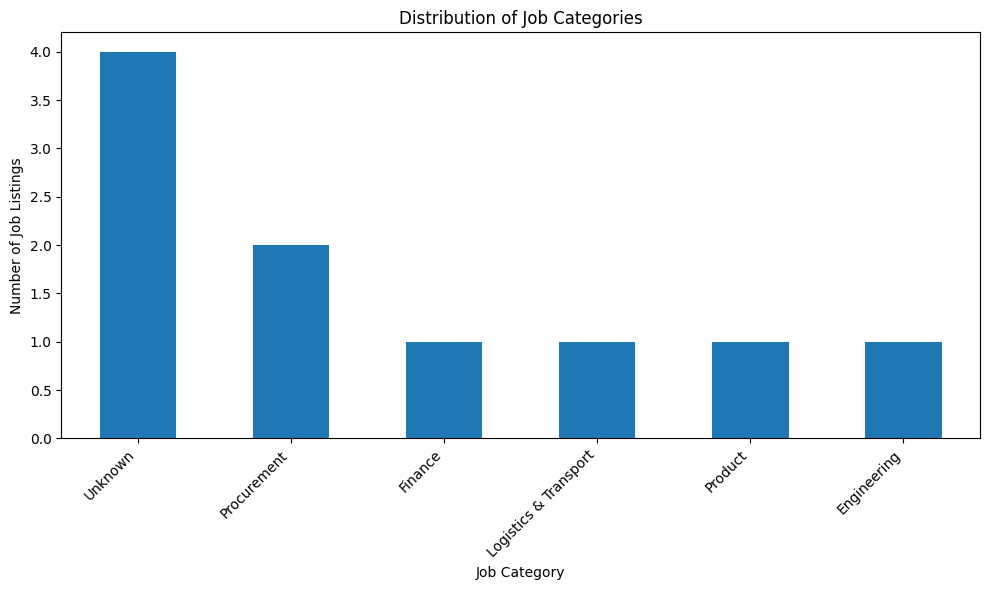

In [119]:
# Job category distribution

category_counts = jobs_df["category"].value_counts()

print(category_counts)

plt.figure(figsize=(10, 6))
category_counts.plot(kind="bar")
plt.title("Distribution of Job Categories")
plt.xlabel("Job Category")
plt.ylabel("Number of Job Listings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.2 Job Locations

Location is analysed to determine where the collected technology job opportunities are concentrated.

Understanding geographic distribution can provide insight into the availability of technology roles across South African locations represented in the dataset.


city
Johannesburg    6
Cape Town       3
Unknown         1
Name: count, dtype: int64


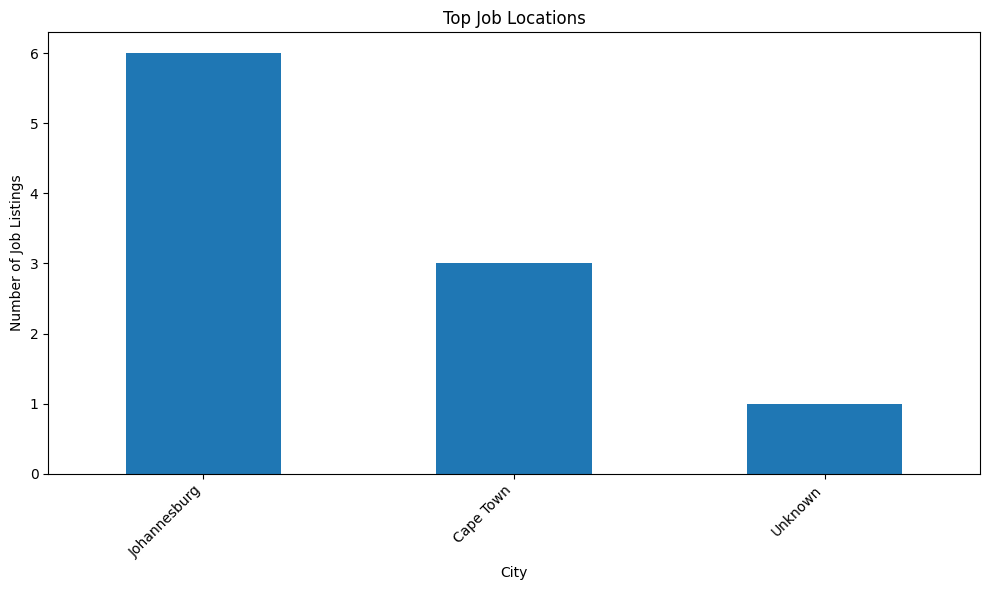

In [120]:
# Job location distribution

location_counts = jobs_df["city"].value_counts().head(10)

print(location_counts)

plt.figure(figsize=(10, 6))
location_counts.plot(kind="bar")
plt.title("Top Job Locations")
plt.xlabel("City")
plt.ylabel("Number of Job Listings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.3 Seniority Levels

The seniority distribution is examined to understand the experience levels represented in the job listings.

This can help identify whether the collected vacancies are primarily targeted at entry-level, intermediate, senior, or management-level candidates.


seniority
Unknown    4
Manager    3
Entry      3
Name: count, dtype: int64


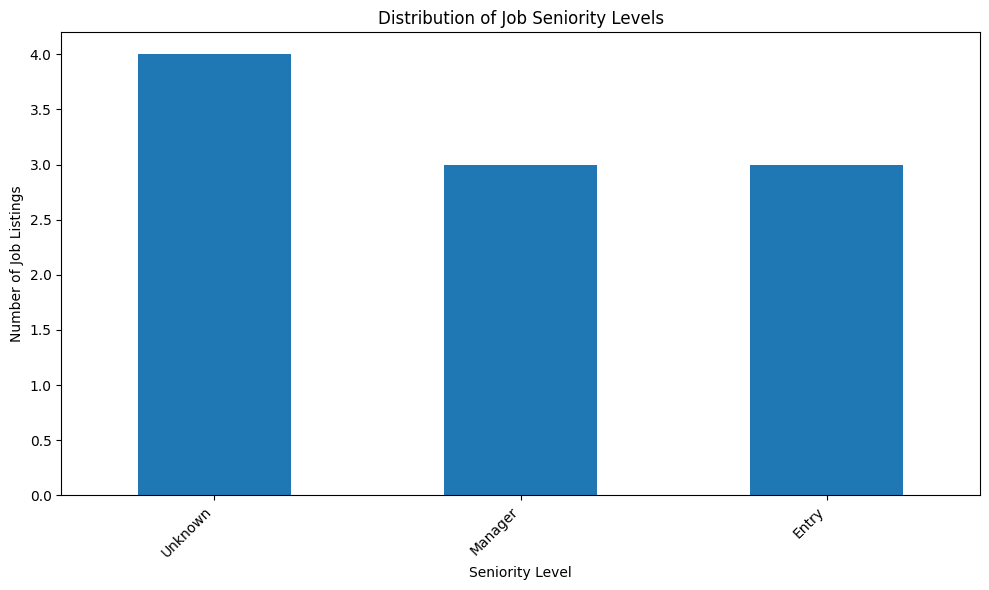

In [121]:
# Seniority distribution

seniority_counts = jobs_df["seniority"].value_counts()

print(seniority_counts)

plt.figure(figsize=(10, 6))
seniority_counts.plot(kind="bar")
plt.title("Distribution of Job Seniority Levels")
plt.xlabel("Seniority Level")
plt.ylabel("Number of Job Listings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 10.4 Remote Work Arrangements

The dataset contains information about whether positions are classified as on-site, remote, or hybrid.

Analysing this field provides an overview of the work arrangements represented in the collected vacancies.


remote
on_site    10
Name: count, dtype: int64


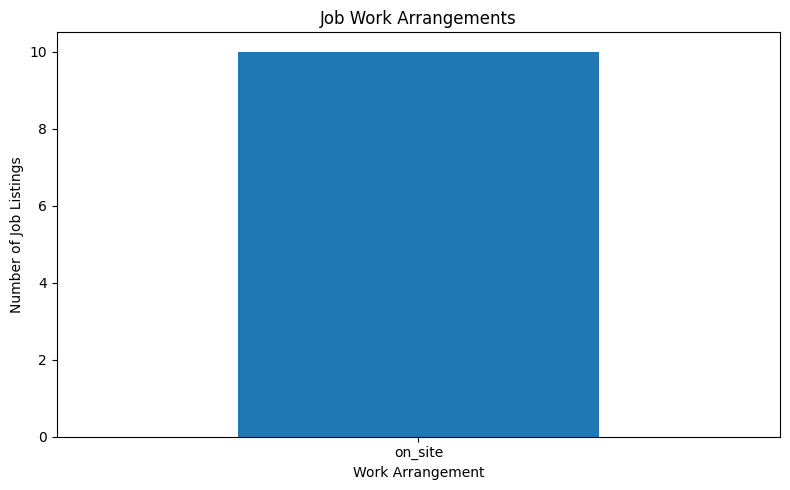

In [122]:
# Remote work distribution

remote_counts = jobs_df["remote"].value_counts()

print(remote_counts)

plt.figure(figsize=(8, 5))
remote_counts.plot(kind="bar")
plt.title("Job Work Arrangements")
plt.xlabel("Work Arrangement")
plt.ylabel("Number of Job Listings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 10.5 Job Description Length

Job-description length is examined because longer descriptions may contain more information about responsibilities, qualifications, skills, and technologies.

Word count and character count provide simple text-based features that will also be useful when preparing the dataset for NLP.


Word count statistics:
count      10.000000
mean      473.100000
std       504.152413
min         0.000000
25%         0.000000
50%       383.000000
75%       969.250000
max      1045.000000
Name: word_count, dtype: float64

Character count statistics:
count      10.00000
mean     3425.30000
std      3670.91109
min         0.00000
25%         0.00000
50%      2679.50000
75%      6972.25000
max      7933.00000
Name: character_count, dtype: float64


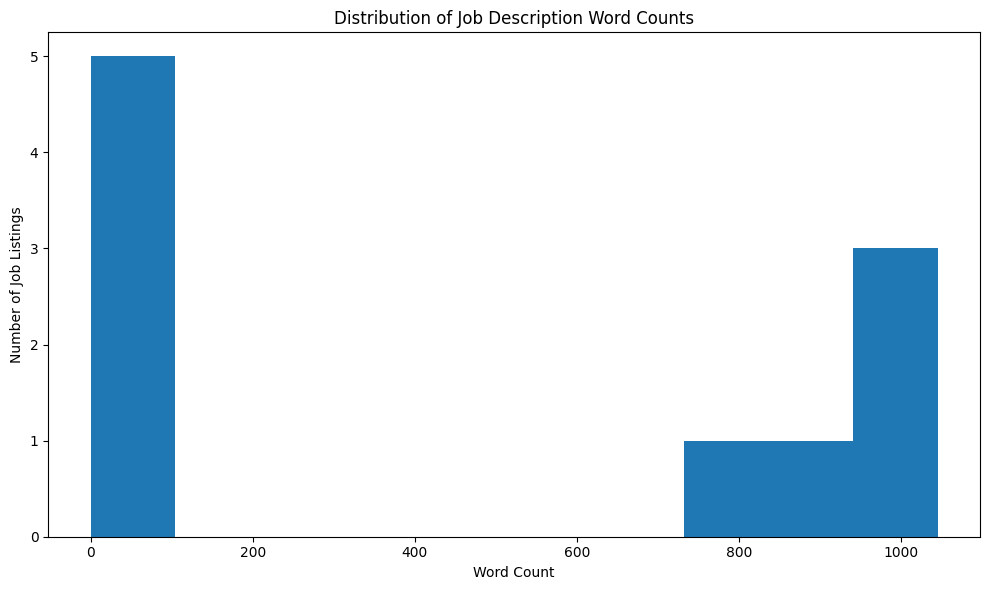

In [123]:
# Job description length statistics

print("Word count statistics:")
print(jobs_df["word_count"].describe())

print("\nCharacter count statistics:")
print(jobs_df["character_count"].describe())

plt.figure(figsize=(10, 6))
plt.hist(jobs_df["word_count"], bins=10)
plt.title("Distribution of Job Description Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Number of Job Listings")
plt.tight_layout()
plt.show()

In [124]:
# Save the cleaned dataset

jobs_df.to_csv(
    "south_african_jobs_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 11. Technical Skills Analysis

Job descriptions contain information about the technical skills, programming languages, tools, platforms, and technologies required by employers.

A predefined list of common technology skills is used to search the collected job descriptions. The frequency of each skill is then calculated to identify which skills appear most often in the dataset.

This provides an initial skills analysis before applying more advanced NLP techniques.


In [125]:
# Define technical skills to search for

technical_skills = [
    "Python",
    "SQL",
    "R",
    "Java",
    "JavaScript",
    "C++",
    "C#",
    "AWS",
    "Azure",
    "Google Cloud",
    "Docker",
    "Kubernetes",
    "Git",
    "GitHub",
    "Power BI",
    "Tableau",
    "Excel",
    "TensorFlow",
    "PyTorch",
    "Scikit-learn",
    "Pandas",
    "NumPy",
    "Machine Learning",
    "Deep Learning",
    "Artificial Intelligence",
    "Data Science",
    "NLP",
    "APIs",
    "Agile",
    "Scrum"
]

print("Number of skills being searched:", len(technical_skills))

Number of skills being searched: 30


In [126]:
# Count technical skills mentioned in job descriptions

skill_counts = {}

job_text = jobs_df["description"].fillna("").str.lower()

for skill in technical_skills:
    skill_lower = skill.lower()

    count = job_text.str.contains(
        skill_lower,
        regex=False
    ).sum()

    skill_counts[skill] = count

skill_counts_df = (
    pd.DataFrame(
        list(skill_counts.items()),
        columns=["Skill", "Job_Count"]
    )
    .sort_values("Job_Count", ascending=False)
)

display(skill_counts_df)

,Skill,Job_Count
2,R,5
16,Excel,3
25,Data Science,2
28,Agile,2
12,Git,2
11,Kubernetes,1
27,APIs,1
1,SQL,1
6,C#,0
7,AWS,0


### 11.1 Most Frequently Mentioned Technical Skills

The extracted skills are ranked according to the number of job descriptions in which they appear.

This analysis provides an initial indication of the technical skills appearing most frequently in the collected South African technology job listings.


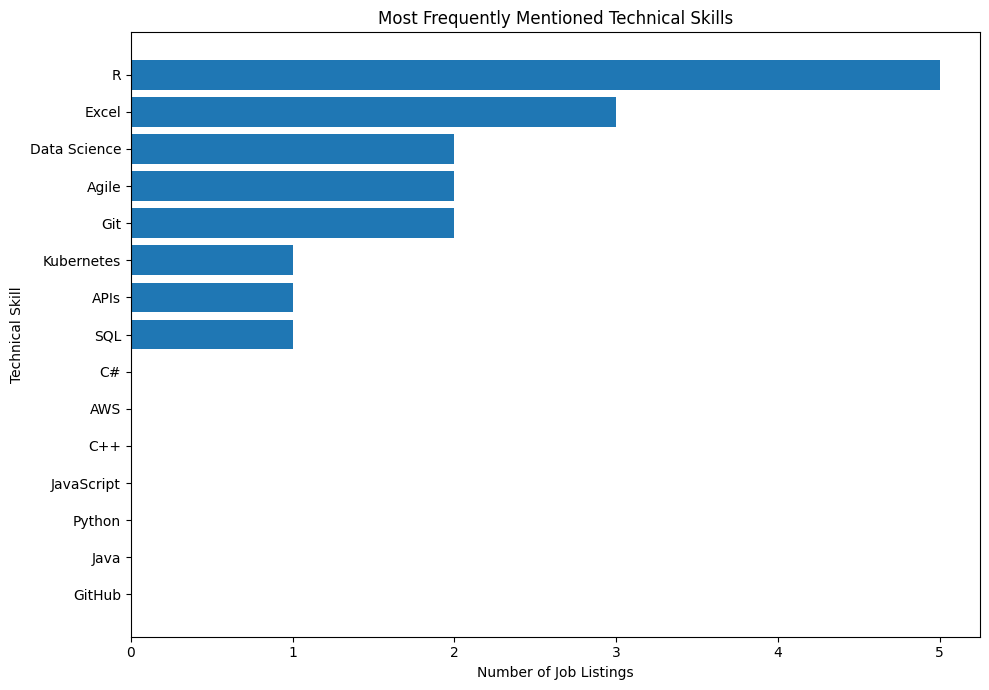

In [127]:
# Visualise the most frequently mentioned skills

top_skills = skill_counts_df.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_skills["Skill"][::-1],
    top_skills["Job_Count"][::-1]
)

plt.title("Most Frequently Mentioned Technical Skills")
plt.xlabel("Number of Job Listings")
plt.ylabel("Technical Skill")

plt.tight_layout()
plt.show()

In [128]:
# Create binary indicators for technical skills

for skill in technical_skills:
    column_name = (
        "skill_"
        + skill.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("#", "sharp")
        .replace("-", "_")
    )

    jobs_df[column_name] = (
        jobs_df["description"]
        .fillna("")
        .str.lower()
        .str.contains(skill.lower(), regex=False)
        .astype(int)
    )

print("Skill indicator features created.")

Skill indicator features created.


In [129]:
# Display skill indicators

skill_columns = [
    column for column in jobs_df.columns
    if column.startswith("skill_")
]

print("Number of skill features:", len(skill_columns))

display(
    jobs_df[
        ["title"] + skill_columns
    ].head()
)

Number of skill features: 30


,title,skill_python,skill_sql,skill_r,skill_java,skill_javascript,skill_cplusplus,skill_csharp,skill_aws,skill_azure,skill_google_cloud,skill_docker,skill_kubernetes,skill_git,skill_github,skill_power_bi,skill_tableau,skill_excel,skill_tensorflow,skill_pytorch,skill_scikit_learn,skill_pandas,skill_numpy,skill_machine_learning,skill_deep_learning,skill_artificial_intelligence,skill_data_science,skill_nlp,skill_apis,skill_agile,skill_scrum
0,Distribution Manager,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Private Banking Relationship Manager,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,Universal Banker,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,Product Manager (Deployment Strategist),0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0
4,Procurement Managed Services Graduate Interns 2027,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [130]:
# Save dataset with skill features

jobs_df.to_csv(
    "south_african_jobs_with_skills.csv",
    index=False
)

print("Dataset with skill features saved successfully!")

Dataset with skill features saved successfully!


## 12. NLP Preprocessing

Natural Language Processing (NLP) is used to convert unstructured job descriptions into numerical features that machine-learning models can understand.

In this section, the job descriptions will be cleaned and transformed into TF-IDF features. TF-IDF gives higher importance to words that are frequent in a particular job description but less common across the dataset.


In [131]:
import re

from sklearn.feature_extraction.text import TfidfVectorizer

print("NLP libraries imported successfully!")

NLP libraries imported successfully!


### 12.1 Cleaning Job Descriptions

Job descriptions may contain HTML, punctuation, numbers, URLs, and other characters that are not useful for basic text analysis. A cleaning function is used to standardise the text before creating NLP features.


In [132]:
def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Keep letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

jobs_df["clean_description"] = jobs_df["description"].apply(clean_text)

print("Text cleaning completed!")
display(
    jobs_df[["description", "clean_description"]].head(3)
)

Text cleaning completed!


,description,clean_description
0,,
1,,
2,,


In [133]:
print("Original description length:")
print(jobs_df["description"].str.len().head())

print("\nCleaned description length:")
print(jobs_df["clean_description"].str.len().head())

Original description length:
0       0
1       0
2       0
3    6424
4    7155
Name: description, dtype: int64

Cleaned description length:
0       0
1       0
2       0
3    6182
4    6854
Name: clean_description, dtype: int64


### 12.2 TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts job-description text into numerical features.

The method measures how important a word is within a job description relative to how frequently that word appears across all job descriptions.

These numerical features can later be used as input for machine-learning models.


In [134]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    stop_words="english"
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    jobs_df["clean_description"]
)

print("TF-IDF matrix created!")
print("Matrix shape:", tfidf_matrix.shape)

TF-IDF matrix created!
Matrix shape: (10, 100)


In [135]:
feature_names = tfidf_vectorizer.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("\nFirst 30 features:")
print(feature_names[:30])

Number of TF-IDF features: 100

First 30 features:
['ability' 'activities' 'advantageous' 'agent' 'ai' 'analyse'
 'applications' 'building' 'business' 'capabilities' 'challenges' 'client'
 'clients' 'code' 'collaboration' 'commercial' 'communication' 'complex'
 'compliance' 'conduct' 'consulting' 'continuous' 'data' 'date' 'degree'
 'deliver' 'delivery' 'design' 'develop' 'developing']


In [136]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names
)

display(tfidf_df.head())

,ability,activities,advantageous,agent,ai,analyse,applications,building,business,capabilities,challenges,client,clients,code,collaboration,commercial,communication,complex,compliance,conduct,consulting,continuous,data,date,degree,deliver,delivery,design,develop,developing,drive,end,engineering,ensure,ensuring,enterprise,environment,equipment,evaluation,experience,firm,governance,guidance,high,including,information,innovation,job,knowledge,lead,learn,level,levels,management,market,members,needs,operational,operations,opportunities,people,performance,processes,procurement,product,production,products,professional,provide,pwc,quality,requirements,retrieval,risks,role,service,services,skills,software,solutions,sourcing,specific,stakeholders,standards,strong,success,supplier,suppliers,support,systems,team,technical,technology,timelines,understanding,use,user,value,way,work
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.110271,0.061394,0.027568,0.039465,0.276254,0.027568,0.0,0.000000,0.137838,0.000000,0.00000,0.030697,0.092091,0.030697,0.027568,0.061394,0.00000,0.153485,0.0,0.027568,0.034527,0.000000,0.061394,0.027568,0.030697,0.110271,0.192974,0.07893,0.122788,0.030697,0.122788,0.137838,0.055135,0.069054,0.034527,0.07893,0.061394,0.0,0.000000,0.137838,0.092091,0.027568,0.027568,0.061394,0.030697,0.000000,0.138108,0.061394,0.082703,0.122788,0.000000,0.061394,0.000000,0.165406,0.061394,0.061394

### 12.3 Most Important Terms

The average TF-IDF score is calculated for each term across the collected job listings. Terms with higher average scores have greater importance within this dataset.


In [137]:
average_tfidf = tfidf_df.mean().sort_values(ascending=False)

top_tfidf_words = average_tfidf.head(20)

display(
    top_tfidf_words.to_frame(name="Average_TFIDF")
)

,Average_TFIDF
procurement,0.102537
supplier,0.073229
business,0.071180
support,0.068200
technical,0.068097
sourcing,0.066998
management,0.065774
team,0.064635
requirements,0.062538
quality,0.062338


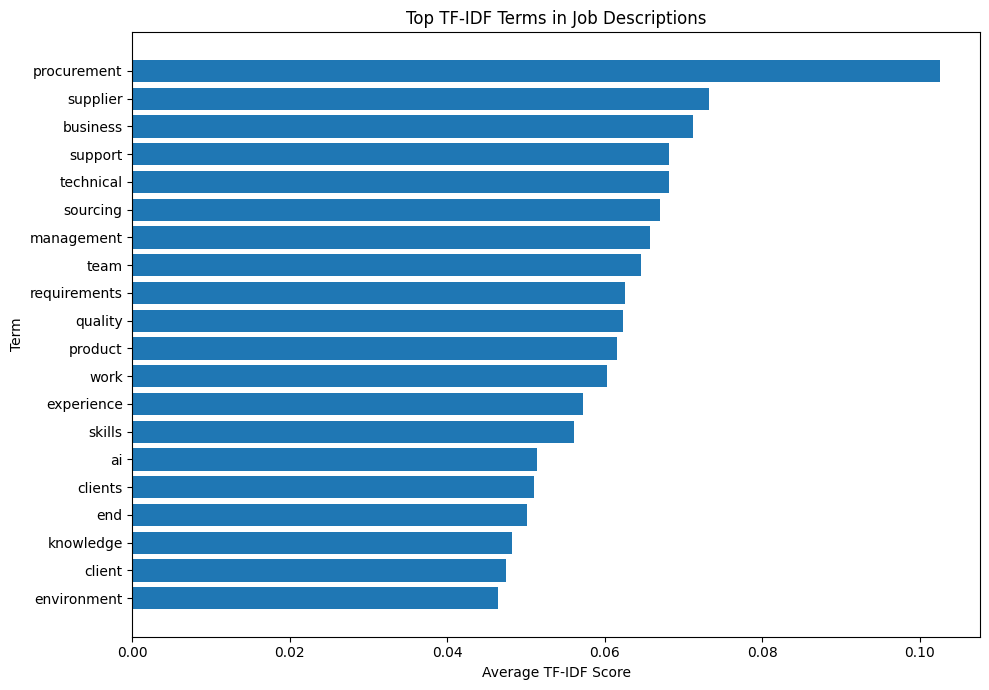

In [138]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_tfidf_words.index[::-1],
    top_tfidf_words.values[::-1]
)

plt.title("Top TF-IDF Terms in Job Descriptions")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Term")

plt.tight_layout()
plt.show()

In [139]:
jobs_df.to_csv(
    "south_african_jobs_nlp.csv",
    index=False
)

tfidf_df.to_csv(
    "south_african_jobs_tfidf.csv",
    index=False
)

print("NLP datasets saved successfully!")

NLP datasets saved successfully!


In [140]:
print("Final dataset shape:", jobs_df.shape)
print("TF-IDF shape:", tfidf_df.shape)

print("\nNLP columns:")
print([
    column for column in jobs_df.columns
    if column in ["description", "clean_description"]
])

Final dataset shape: (10, 59)
TF-IDF shape: (10, 100)

NLP columns:
['description', 'clean_description']


## 13. Machine Learning

The machine-learning stage uses the processed job descriptions and extracted features to classify job postings according to whether they represent technology-related roles.

A target variable will be created from the available job categories. The data will then be divided into training and testing sets before machine-learning models are trained and evaluated.


In [141]:
print("Job categories:")
print(jobs_df["category"].value_counts())

Job categories:
category
Unknown                  4
Procurement              2
Finance                  1
Logistics & Transport    1
Product                  1
Engineering              1
Name: count, dtype: int64


In [142]:
technology_keywords = [
    "technology",
    "tech",
    "software",
    "data",
    "information technology",
    "it",
    "engineering",
    "developer",
    "development",
    "cyber",
    "cloud"
]

def classify_technology_job(row):
    text = (
        str(row["title"]) + " " +
        str(row["category"]) + " " +
        str(row["description"])
    ).lower()

    return int(
        any(keyword in text for keyword in technology_keywords)
    )

jobs_df["is_technology_job"] = jobs_df.apply(
    classify_technology_job,
    axis=1
)

print("Technology-job target created.")
print(jobs_df["is_technology_job"].value_counts())

Technology-job target created.
is_technology_job
0    5
1    5
Name: count, dtype: int64


### 13.1 Target Variable

The target variable `is_technology_job` indicates whether a job listing has been classified as a technology-related role.

A value of `1` represents a technology-related job, while `0` represents a non-technology-related job.


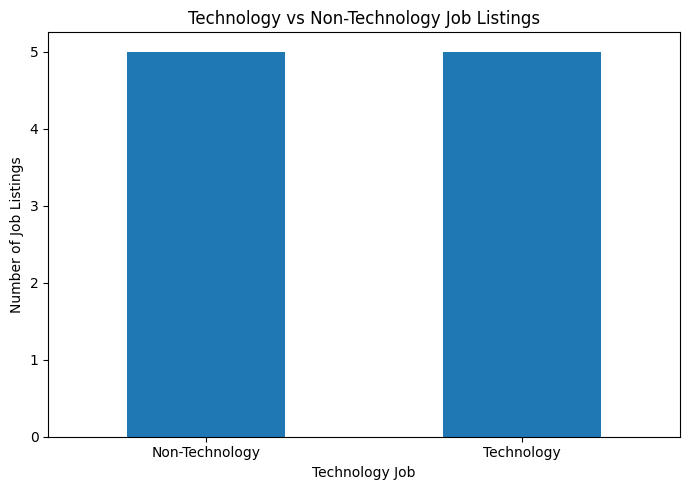

In [143]:
plt.figure(figsize=(7, 5))

jobs_df["is_technology_job"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Technology vs Non-Technology Job Listings")
plt.xlabel("Technology Job")
plt.ylabel("Number of Job Listings")
plt.xticks(
    [0, 1],
    ["Non-Technology", "Technology"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [144]:
target_counts = jobs_df["is_technology_job"].value_counts()

print("Target distribution:")
print(target_counts)

if len(target_counts) < 2:
    print("\nWARNING: Only one target class exists.")
    print("More job listings are required before classification.")
else:
    print("\nBoth target classes are present.")

Target distribution:
is_technology_job
0    5
1    5
Name: count, dtype: int64

Both target classes are present.


In [145]:
X = tfidf_matrix
y = jobs_df["is_technology_job"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (10, 100)
Target shape: (10,)


### 13.2 Training and Testing Data

The dataset is divided into training and testing subsets.

The training data is used to learn patterns from job descriptions, while the testing data is used to evaluate how well the trained model performs on unseen data.


In [146]:
from sklearn.model_selection import train_test_split

if y.nunique() == 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Training data:", X_train.shape)
    print("Testing data:", X_test.shape)
else:
    print("Train/test split skipped because only one target class exists.")

Training data: (8, 100)
Testing data: (2, 100)


In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Classification models imported successfully!")

Classification models imported successfully!


### 13.3 Logistic Regression

Logistic Regression is a classification algorithm that estimates the probability that an observation belongs to a particular class.

It will be used as a baseline model for classifying technology-related job listings.


In [148]:
if y.nunique() == 2:
    logistic_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    logistic_model.fit(X_train, y_train)

    logistic_predictions = logistic_model.predict(X_test)

    print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### 13.4 Random Forest

Random Forest is an ensemble classification algorithm that combines multiple decision trees to make predictions.

It provides a second model that can be compared with Logistic Regression.


In [149]:
if y.nunique() == 2:
    random_forest_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    random_forest_model.fit(X_train, y_train)

    random_forest_predictions = random_forest_model.predict(X_test)

    print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [150]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

if y.nunique() == 2:
    models_results = []

    for model_name, predictions in [
        ("Logistic Regression", logistic_predictions),
        ("Random Forest", random_forest_predictions)
    ]:
        models_results.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, predictions),
            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_test,
                predictions,
                zero_division=0
            )
        })

    model_results_df = pd.DataFrame(models_results)

    display(model_results_df)
else:
    print("Model evaluation skipped because only one target class exists.")

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


In [151]:
if y.nunique() == 2:
    print("=== LOGISTIC REGRESSION ===")
    print(
        classification_report(
            y_test,
            logistic_predictions,
            zero_division=0
        )
    )

    print("\n=== RANDOM FOREST ===")
    print(
        classification_report(
            y_test,
            random_forest_predictions,
            zero_division=0
        )
    )

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [152]:
if y.nunique() == 2:
    model_results_df.to_csv(
        "model_comparison_results.csv",
        index=False
    )

    print("Model comparison results saved successfully!")

Model comparison results saved successfully!


## 14. Hyperparameter Tuning

Hyperparameter tuning is used to identify model settings that can improve classification performance.

`GridSearchCV` tests different combinations of hyperparameters using cross-validation and selects the combination that produces the best validation performance.


In [153]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully!")

GridSearchCV imported successfully!


In [154]:
if y.nunique() == 2:
    logistic_parameters = {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]
    }

    logistic_grid = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        logistic_parameters,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    logistic_grid.fit(X_train, y_train)

    print("Best Logistic Regression parameters:")
    print(logistic_grid.best_params_)

    print("\nBest cross-validation F1 score:")
    print(logistic_grid.best_score_)

Best Logistic Regression parameters:
{'C': 1, 'solver': 'liblinear'}

Best cross-validation F1 score:
1.0


In [155]:
if y.nunique() == 2:
    random_forest_parameters = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 5, 10],
        "min_samples_split": [2, 5]
    }

    random_forest_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        random_forest_parameters,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    random_forest_grid.fit(X_train, y_train)

    print("Best Random Forest parameters:")
    print(random_forest_grid.best_params_)

    print("\nBest cross-validation F1 score:")
    print(random_forest_grid.best_score_)

Best Random Forest parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

Best cross-validation F1 score:
1.0


### 14.1 Tuned Model Evaluation

The best-performing models identified by GridSearchCV are evaluated on the previously unseen test data.

Accuracy, precision, recall, and F1-score are used to assess classification performance.


In [156]:
if y.nunique() == 2:
    tuned_logistic_predictions = logistic_grid.predict(X_test)
    tuned_rf_predictions = random_forest_grid.predict(X_test)

    tuned_results = pd.DataFrame([
        {
            "Model": "Tuned Logistic Regression",
            "Accuracy": accuracy_score(
                y_test,
                tuned_logistic_predictions
            ),
            "Precision": precision_score(
                y_test,
                tuned_logistic_predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                tuned_logistic_predictions,
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_test,
                tuned_logistic_predictions,
                zero_division=0
            )
        },
        {
            "Model": "Tuned Random Forest",
            "Accuracy": accuracy_score(
                y_test,
                tuned_rf_predictions
            ),
            "Precision": precision_score(
                y_test,
                tuned_rf_predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                tuned_rf_predictions,
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_test,
                tuned_rf_predictions,
                zero_division=0
            )
        }
    ])

    display(tuned_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,1.0,1.0,1.0,1.0
1,Tuned Random Forest,1.0,1.0,1.0,1.0


## 15. Confusion Matrix

A confusion matrix shows how many predictions were correctly or incorrectly classified.

It separates predictions into true positives, true negatives, false positives, and false negatives, providing more detail than accuracy alone.


In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if y.nunique() == 2:
    logistic_cm = confusion_matrix(
        y_test,
        tuned_logistic_predictions
    )

    rf_cm = confusion_matrix(
        y_test,
        tuned_rf_predictions
    )

    print("Logistic Regression Confusion Matrix:")
    print(logistic_cm)

    print("\nRandom Forest Confusion Matrix:")
    print(rf_cm)

Logistic Regression Confusion Matrix:
[[1 0]
 [0 1]]

Random Forest Confusion Matrix:
[[1 0]
 [0 1]]


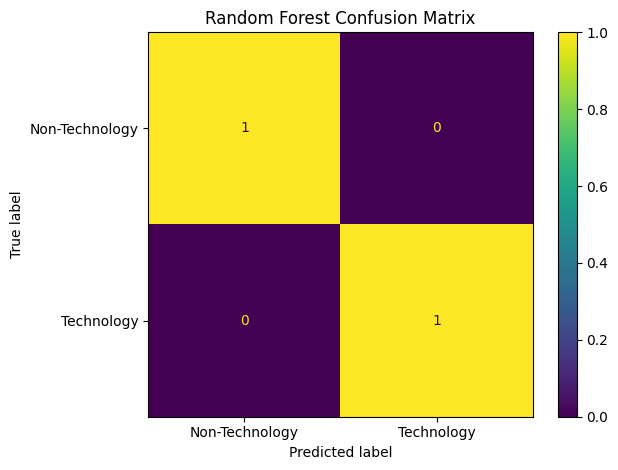

In [158]:
if y.nunique() == 2:
    ConfusionMatrixDisplay(
        confusion_matrix=rf_cm,
        display_labels=["Non-Technology", "Technology"]
    ).plot()

    plt.title("Random Forest Confusion Matrix")
    plt.tight_layout()
    plt.show()

## 16. Feature Importance

Feature importance identifies which words contributed most strongly to the Random Forest model's classification decisions.

This provides insight into the language and terms associated with technology-related job listings in the collected dataset.


In [159]:
if y.nunique() == 2:
    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": random_forest_grid.best_estimator_.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        "Importance",
        ascending=False
    )

    display(feature_importance.head(20))

,Feature,Importance
79,solutions,0.06
91,technical,0.06
0,ability,0.04
26,delivery,0.04
81,specific,0.04
82,stakeholders,0.04
76,services,0.04
73,risks,0.04
98,way,0.04
56,needs,0.04


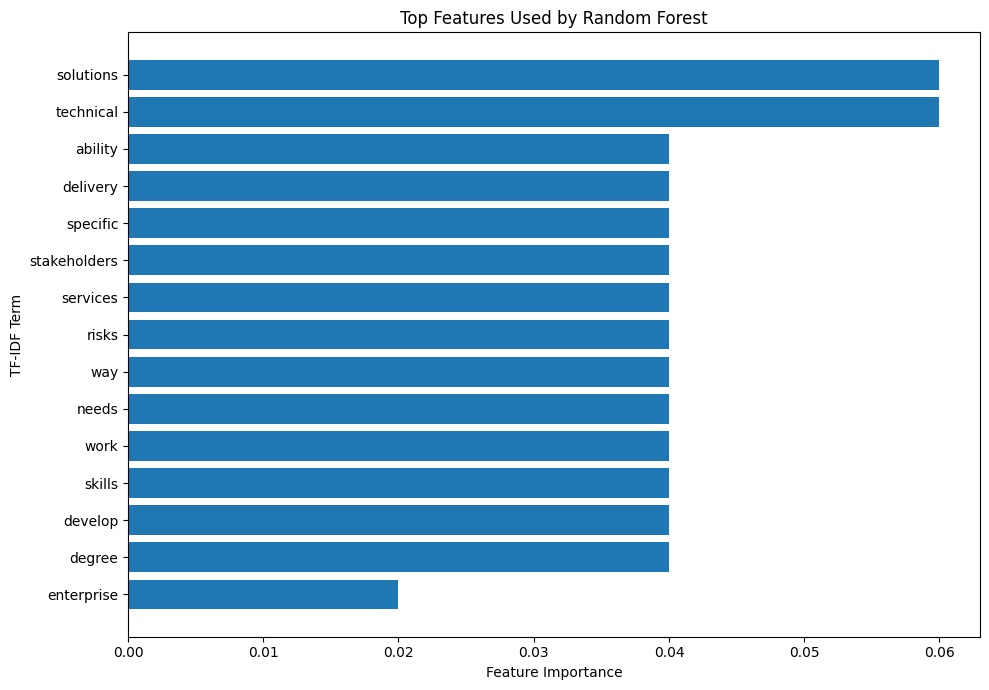

In [160]:
if y.nunique() == 2:
    top_features = feature_importance.head(15)

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )

    plt.title("Top Features Used by Random Forest")
    plt.xlabel("Feature Importance")
    plt.ylabel("TF-IDF Term")

    plt.tight_layout()
    plt.show()

## 17. Saving the Final Model

The tuned Random Forest model is saved using `joblib`. Saving the trained model allows it to be reused later without retraining it from the beginning.


In [161]:
import joblib

if y.nunique() == 2:
    final_model = random_forest_grid.best_estimator_

    joblib.dump(
        final_model,
        "south_african_job_classifier.pkl"
    )

    joblib.dump(
        tfidf_vectorizer,
        "job_description_tfidf_vectorizer.pkl"
    )

    print("Final model saved successfully!")
    print("TF-IDF vectorizer saved successfully!")

Final model saved successfully!
TF-IDF vectorizer saved successfully!


In [162]:
jobs_df.to_csv(
    "final_south_african_jobs_dataset.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [163]:
print("===================================")
print("PROJECT COMPLETION CHECK")
print("===================================")

print("Dataset shape:", jobs_df.shape)
print("Number of job listings:", len(jobs_df))
print("Number of technical skill features:", len(skill_columns))
print("Number of TF-IDF features:", len(feature_names))

if y.nunique() == 2:
    print("\nTarget distribution:")
    print(y.value_counts())

    print("\nTuned model results:")
    display(tuned_results)

print("\nProject files created:")
print("- south_african_jobs_cleaned.csv")
print("- south_african_jobs_with_skills.csv")
print("- south_african_jobs_nlp.csv")
print("- south_african_jobs_tfidf.csv")
print("- model_comparison_results.csv")
print("- south_african_job_classifier.pkl")
print("- job_description_tfidf_vectorizer.pkl")
print("- final_south_african_jobs_dataset.csv")

PROJECT COMPLETION CHECK
Dataset shape: (10, 60)
Number of job listings: 10
Number of technical skill features: 30
Number of TF-IDF features: 100

Target distribution:
is_technology_job
0    5
1    5
Name: count, dtype: int64

Tuned model results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,1.0,1.0,1.0,1.0
1,Tuned Random Forest,1.0,1.0,1.0,1.0



Project files created:
- south_african_jobs_cleaned.csv
- south_african_jobs_with_skills.csv
- south_african_jobs_nlp.csv
- south_african_jobs_tfidf.csv
- model_comparison_results.csv
- south_african_job_classifier.pkl
- job_description_tfidf_vectorizer.pkl
- final_south_african_jobs_dataset.csv


## 18. Interactive Prediction Interface

The trained machine-learning model can be used to classify a new job description. The prediction function below cleans the supplied description, converts it into TF-IDF features using the fitted vectorizer, and returns the predicted job category.


In [164]:
def predict_job_type(job_description):
    cleaned_description = clean_text(job_description)

    transformed_text = tfidf_vectorizer.transform(
        [cleaned_description]
    )

    prediction = final_model.predict(transformed_text)[0]

    if prediction == 1:
        result = "Technology-related job"
    else:
        result = "Non-technology-related job"

    return result

In [165]:
sample_job = """
We are looking for a Python developer with experience in SQL,
machine learning, APIs, Git and cloud technologies.
The candidate will develop software applications and work
with data engineering teams.
"""

prediction = predict_job_type(sample_job)

print("Prediction:", prediction)

Prediction: Non-technology-related job


In [166]:
sample_job_2 = """
We are looking for a retail sales consultant.
The successful candidate will assist customers,
manage products and provide excellent customer service.
"""

prediction_2 = predict_job_type(sample_job_2)

print("Prediction:", prediction_2)

Prediction: Non-technology-related job


## 19. Project Findings

The analysis identified patterns in the collected South African job listings, including job categories, locations, seniority levels, remote-work arrangements, job-description characteristics and frequently mentioned technical skills.

The technical-skills analysis provides an overview of the technologies appearing in the collected sample, while TF-IDF analysis identifies terms that were particularly important within the job descriptions.

The machine-learning stage demonstrates how Natural Language Processing can be combined with classification algorithms to classify job listings according to their technology-related characteristics.


## 20. Limitations

There are several limitations to this analysis.

1. The collected dataset contains a small number of job listings, so the results should not be treated as representative of the entire South African job market.

2. Technical skills were identified using a predefined list of keywords. Skills that were not included in the list may therefore have been missed.

3. The technology-job classification target was created using keyword-based rules, which may introduce classification errors.

4. Job descriptions can contain different terminology for similar technologies or skills.

5. The machine-learning results are based on a small dataset and should therefore be interpreted cautiously.

6. Job-market conditions change over time, meaning that the findings represent the listings collected during this project rather than permanent trends.


## 21. Recommendations

Future versions of the project could improve the analysis by collecting a substantially larger number of South African job listings.

Additional improvements could include:

* Collecting job listings over a longer period.
* Including more job boards and job sources.
* Expanding the technical-skills dictionary.
* Applying more advanced NLP techniques.
* Using additional machine-learning algorithms.
* Performing more extensive hyperparameter tuning.
* Building an interactive dashboard for job-market exploration.
* Regularly updating the dataset to monitor changes in demand for skills.


## 22. Conclusion

This project investigated the South African job market using job-listing data, exploratory data analysis, technical-skill extraction, Natural Language Processing and machine learning.

The analysis examined characteristics such as job categories, locations, seniority, remote-work arrangements and job-description length. A predefined technical-skills dictionary was also used to identify frequently mentioned technologies and skills.

NLP techniques were applied to clean job descriptions and transform them into TF-IDF numerical features. These features were then used to train classification models, including Logistic Regression and Random Forest.

GridSearchCV was used to tune the machine-learning models, while accuracy, precision, recall and F1-score were used for evaluation.

Overall, the project demonstrates a complete data-science workflow, from data collection and cleaning through exploratory analysis, feature engineering, NLP, machine learning, model evaluation and prediction.

The results should be interpreted within the limitations of the collected dataset, particularly its relatively small size. A larger and more diverse dataset would allow more reliable conclusions about the South African job market.


In [167]:
print("========================================")
print(" SOUTH AFRICAN JOB MARKET INTELLIGENCE ")
print("========================================")

print("\nDataset:")
print("Rows:", jobs_df.shape[0])
print("Columns:", jobs_df.shape[1])

print("\nNLP:")
print("TF-IDF features:", len(feature_names))

print("\nSkills:")
print("Technical skill features:", len(skill_columns))

print("\nMachine Learning:")
if y.nunique() == 2:
    print("Target classes:", y.nunique())
    print("\nModel results:")
    display(tuned_results)

print("\nSaved files:")
print("✓ final_south_african_jobs_dataset.csv")
print("✓ south_african_job_classifier.pkl")
print("✓ job_description_tfidf_vectorizer.pkl")

print("\nPROJECT PIPELINE COMPLETE!")

 SOUTH AFRICAN JOB MARKET INTELLIGENCE 

Dataset:
Rows: 10
Columns: 60

NLP:
TF-IDF features: 100

Skills:
Technical skill features: 30

Machine Learning:
Target classes: 2

Model results:


,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Logistic Regression,1.0,1.0,1.0,1.0
1,Tuned Random Forest,1.0,1.0,1.0,1.0



Saved files:
✓ final_south_african_jobs_dataset.csv
✓ south_african_job_classifier.pkl
✓ job_description_tfidf_vectorizer.pkl

PROJECT PIPELINE COMPLETE!
